<>:38: SyntaxWarning: invalid escape sequence '\A'
<>:43: SyntaxWarning: invalid escape sequence '\A'
<>:38: SyntaxWarning: invalid escape sequence '\A'
<>:43: SyntaxWarning: invalid escape sequence '\A'
C:\Users\julia\AppData\Local\Temp\ipykernel_1948\1718865754.py:38: SyntaxWarning: invalid escape sequence '\A'
  ax1.text(3.6, 13.7, '0.95 $\AA$ ($\Delta c = 6.7\%$)', color='#D64030')
C:\Users\julia\AppData\Local\Temp\ipykernel_1948\1718865754.py:43: SyntaxWarning: invalid escape sequence '\A'
  ax1.text(4.35, 14.2, '0.48 $\AA$', color='#5B9BD5')


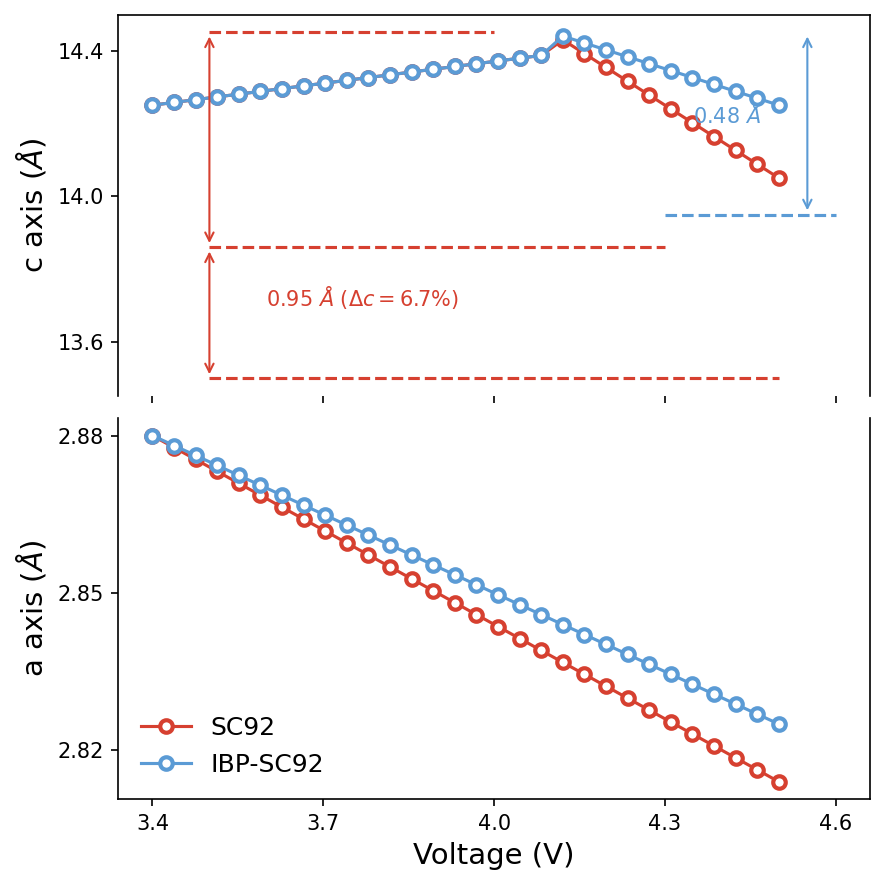

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
voltage = np.linspace(3.4, 4.5, 30)

# Top Panel: c axis
# SC92 (Red) - Collapses
c_sc92 = 14.25 + 0.2 * np.exp(-((voltage - 4.0)/0.3)**2)
# Actually it goes up then down
c_sc92 = 14.25 + 0.2 * (voltage - 3.4)
mask_drop = voltage > 4.1
c_sc92[mask_drop] = 14.45 - 1.0 * (voltage[mask_drop] - 4.1)

# IBP-SC92 (Blue) - Stable
c_ibp = 14.25 + 0.2 * (voltage - 3.4)
c_ibp[mask_drop] = 14.45 - 0.5 * (voltage[mask_drop] - 4.1) # Less drop

# Bottom Panel: a axis
# Both decrease linearly
a_sc92 = 2.88 - 0.06 * (voltage - 3.4)
a_ibp = 2.88 - 0.05 * (voltage - 3.4) # Slightly less

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), dpi=150, sharex=True)

# Top Panel (c axis)
ax1.plot(voltage, c_sc92, 'o-', color='#D64030', mfc='white', mew=2, label='SC92')
ax1.plot(voltage, c_ibp, 'o-', color='#5B9BD5', mfc='white', mew=2, label='IBP-SC92')
ax1.set_ylabel(r'c axis ($\AA$)', fontsize=14)

# Annotations (Dashed lines)
ax1.hlines(14.45, 3.5, 4.0, color='#D64030', linestyle='--')
ax1.hlines(13.86, 3.5, 4.3, color='#D64030', linestyle='--')
ax1.hlines(13.50, 3.5, 4.5, color='#D64030', linestyle='--')
ax1.annotate('', xy=(3.5, 14.45), xytext=(3.5, 13.86), arrowprops=dict(arrowstyle='<->', color='#D64030'))
ax1.annotate('', xy=(3.5, 13.86), xytext=(3.5, 13.50), arrowprops=dict(arrowstyle='<->', color='#D64030'))
ax1.text(3.6, 13.7, r'0.95 $\AA$ ($\Delta c = 6.7\%$)', color='#D64030')

# Blue annotation
ax1.hlines(13.95, 4.3, 4.6, color='#5B9BD5', linestyle='--')
ax1.annotate('', xy=(4.55, 14.45), xytext=(4.55, 13.95), arrowprops=dict(arrowstyle='<->', color='#5B9BD5'))
ax1.text(4.35, 14.2, r'0.48 $\AA$', color='#5B9BD5')

# Bottom Panel (a axis)
ax2.plot(voltage, a_sc92, 'o-', color='#D64030', mfc='white', mew=2, label='SC92')
ax2.plot(voltage, a_ibp, 'o-', color='#5B9BD5', mfc='white', mew=2, label='IBP-SC92')
ax2.set_ylabel(r'a axis ($\AA$)', fontsize=14)
ax2.set_xlabel('Voltage (V)', fontsize=14)
ax2.legend(frameon=False, loc='lower left', fontsize=12)

# Ticks
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.set_yticks([13.6, 14.0, 14.4])
ax2.set_yticks([2.82, 2.85, 2.88])
ax2.set_xticks([3.4, 3.7, 4.0, 4.3, 4.6])

plt.tight_layout()
plt.show()
